### Notebook 1 Overview

This notebook establishes the finalized data and feature foundation for the Fraud Risk Intelligence Platform.

The workflow covers:

* Raw transaction loading and inspection
* Data quality and target validation
* Fraud prevalence and scenario analysis
* Temporal and entity-level analysis
* Chronological train, validation, and test separation
* Leakage-safe feature engineering
* Model feature schema validation
* Model-ready dataset preparation
* Numerical quality and dataset separation checks
* Persistence of the finalized engineered datasets

Model development, validation, threshold analysis, model selection, business-cost evaluation, and final model evaluation are performed in Notebook 2.

The reusable application components used here are limited to the data-loading, chronological-splitting, and model-data preparation functions required by this notebook.


In [14]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

## Project Path Setup

The notebook is executed from the `notebooks` directory, while the reusable application code is stored in the project root under `app/`.

The project root is added to the Python path before importing reusable components.

In [15]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Current working directory:")
print(Path.cwd())

print("\nProject root:")
print(PROJECT_ROOT)

print("\nProject root exists:")
print(PROJECT_ROOT.exists())

print("\nApp directory exists:")
print((PROJECT_ROOT / "app").exists())

print("\nRequirements file exists:")
print((PROJECT_ROOT / "requirements.txt").exists())

Current working directory:
c:\AI\fraud-risk-intelligence-platform\notebooks

Project root:
c:\AI\fraud-risk-intelligence-platform

Project root exists:
True

App directory exists:
True

Requirements file exists:
True


## Import Reusable Project Components

The notebook imports reusable components from the existing project architecture rather than recreating the same logic inside the notebook.

The components are grouped by responsibility:

- data loading
- time-based data splitting
- feature preparation
- model evaluation
- business cost analysis
- benchmarking
- prediction error analysis

In [16]:

from app.data_loader.loader import load_transactions
from app.data_loader.split import split_by_time
from app.features.preprocessing import (
    MODEL_FEATURES,
    TARGET_COLUMN,
    prepare_model_data,
)

print("Reusable project components imported successfully.")



Reusable project components imported successfully.


## Reusable Component Availability Check

A simple audit is performed before model analysis begins.

The purpose is to confirm that the notebook can access the reusable components that will be used throughout the project.

In [17]:

reusable_components = {
    "load_transactions": load_transactions,
    "split_by_time": split_by_time,
    "prepare_model_data": prepare_model_data,
}

print("Reusable data and preprocessing components validated.")


Reusable data and preprocessing components validated.


### Result

All required reusable components were successfully imported and verified.

The notebook can now use the shared project implementation for data loading, time-based splitting, feature preparation, model evaluation, business cost analysis, benchmarking, and prediction error analysis.

This environment check is completed before any model or notebook-specific analysis is performed.

In [18]:

component_check = pd.DataFrame(
    [
        {
            "component": "load_transactions",
            "available": callable(load_transactions),
        },
        {
            "component": "split_by_time",
            "available": callable(split_by_time),
        },
        {
            "component": "prepare_model_data",
            "available": callable(prepare_model_data),
        },
    ]
)

display(component_check)

setup_summary = pd.DataFrame(
    [
        {
            "check": "Pandas available",
            "status": True,
        },
        {
            "check": "Project root detected",
            "status": PROJECT_ROOT.exists(),
        },
        {
            "check": "App directory detected",
            "status": (PROJECT_ROOT / "app").exists(),
        },
        {
            "check": "Requirements file detected",
            "status": (PROJECT_ROOT / "requirements.txt").exists(),
        },
        {
            "check": "Reusable components imported",
            "status": component_check["available"].all(),
        },
    ]
)

display(setup_summary)

assert setup_summary["status"].all()
print("Environment setup completed successfully.")



,component,available
0,load_transactions,True
1,split_by_time,True
2,prepare_model_data,True


,check,status
0,Pandas available,True
1,Project root detected,True
2,App directory detected,True
3,Requirements file detected,True
4,Reusable components imported,True


Environment setup completed successfully.


# 2. Load and Inspect the Raw Dataset

After verifying the project environment and reusable components, the next step is to load the transaction dataset and inspect its basic structure.

The raw dataset is loaded through the reusable project loader to keep data access consistent across the application and analysis workflow. The initial inspection focuses on dataset size, column structure, data types, and a preview of the available transaction records.

This establishes the starting point for data quality checks and exploratory analysis.


In [19]:
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "dataset.zip"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset file not found: {DATA_PATH}"
    )

transactions = load_transactions(DATA_PATH)

print("Transactions loaded successfully.")
print(f"Dataset shape: {transactions.shape}")

Transactions loaded successfully.
Dataset shape: (1754155, 9)


## Dataset Preview

A preview of the dataset is examined before performing detailed analysis. This helps verify that the data loaded correctly and provides an initial view of the transaction-level fields and record structure.


In [20]:
transactions.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0,0,0
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0,0,0


In [21]:
transactions.tail()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
1754150,1754150,2018-09-30 23:56:36,161,655,54.24,15810996,182,0,0
1754151,1754151,2018-09-30 23:57:38,4342,6181,1.23,15811058,182,0,0
1754152,1754152,2018-09-30 23:58:21,618,1502,6.62,15811101,182,0,0
1754153,1754153,2018-09-30 23:59:52,4056,3067,55.40,15811192,182,0,0
1754154,1754154,2018-09-30 23:59:57,3542,9849,23.59,15811197,182,0,0


## Dataset Structure and Data Types

The dataset structure is inspected to understand the available variables, data types, non-null counts, and overall memory usage. This step is important for identifying potential data quality issues before feature analysis and model development.


In [22]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754155 entries, 0 to 1754154
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   TRANSACTION_ID     int64         
 1   TX_DATETIME        datetime64[ns]
 2   CUSTOMER_ID        object        
 3   TERMINAL_ID        object        
 4   TX_AMOUNT          float64       
 5   TX_TIME_SECONDS    object        
 6   TX_TIME_DAYS       object        
 7   TX_FRAUD           int64         
 8   TX_FRAUD_SCENARIO  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 120.4+ MB


## Dataset Dimensions and Available Features

The dataset dimensions and column names are reviewed to document the structure of the raw transaction data. This provides a clear reference for the subsequent data quality and exploratory analysis steps.


In [23]:
dataset_overview = pd.DataFrame(
    {
        "metric": [
            "total_records",
            "total_columns",
        ],
        "value": [
            transactions.shape[0],
            transactions.shape[1],
        ],
    }
)

display(dataset_overview)

print("Available columns:")
print(transactions.columns.tolist())

,metric,value
0,total_records,1754155
1,total_columns,9


Available columns:
['TRANSACTION_ID', 'TX_DATETIME', 'CUSTOMER_ID', 'TERMINAL_ID', 'TX_AMOUNT', 'TX_TIME_SECONDS', 'TX_TIME_DAYS', 'TX_FRAUD', 'TX_FRAUD_SCENARIO']


## Feature Data Types

A structured summary of feature data types is created to identify numeric, categorical, datetime, and other variable types present in the dataset. This will support the later data quality and preprocessing decisions.


In [24]:
data_type_summary = (
    transactions.dtypes
    .astype(str)
    .value_counts()
    .rename_axis("data_type")
    .reset_index(name="feature_count")
)

display(data_type_summary)

,data_type,feature_count
0,object,4
1,int64,3
2,datetime64[ns],1
3,float64,1


In [25]:
column_summary = pd.DataFrame(
    {
        "column": transactions.columns,
        "data_type": transactions.dtypes.astype(str).values,
    }
)

display(column_summary)

,column,data_type
0,TRANSACTION_ID,int64
1,TX_DATETIME,datetime64[ns]
2,CUSTOMER_ID,object
3,TERMINAL_ID,object
4,TX_AMOUNT,float64
5,TX_TIME_SECONDS,object
6,TX_TIME_DAYS,object
7,TX_FRAUD,int64
8,TX_FRAUD_SCENARIO,int64


# 3. Data Quality Assessment

Before exploring fraud patterns or preparing model features, the raw dataset is checked for common data quality issues.

The assessment focuses on missing values, duplicate records, data-type consistency, identifier integrity, target validity, and chronological ordering. These checks help distinguish genuine data issues from expected dataset characteristics before any transformations are applied.


In [26]:
missing_value_summary = (
    transactions.isnull()
    .sum()
    .rename("missing_values")
    .reset_index()
    .rename(columns={"index": "column"})
)

missing_value_summary["missing_percentage"] = (
    missing_value_summary["missing_values"]
    / len(transactions)
    * 100
)

missing_value_summary = missing_value_summary.sort_values(
    "missing_values",
    ascending=False,
).reset_index(drop=True)

display(missing_value_summary)

,column,missing_values,missing_percentage
0,TRANSACTION_ID,0,0.0
1,TX_DATETIME,0,0.0
2,CUSTOMER_ID,0,0.0
3,TERMINAL_ID,0,0.0
4,TX_AMOUNT,0,0.0
5,TX_TIME_SECONDS,0,0.0
6,TX_TIME_DAYS,0,0.0
7,TX_FRAUD,0,0.0
8,TX_FRAUD_SCENARIO,0,0.0


## Missing Value Check

Missing values are examined across all variables before any cleaning decisions are made. Both absolute counts and percentages are reported to identify whether incomplete records could affect exploratory analysis or downstream modeling.


## Duplicate Record Analysis

Duplicate checks are performed at both the full-record and transaction-identifier level. Repeated customers or terminals are expected because individual entities can perform multiple transactions.

The key integrity check is therefore whether complete transaction records or unique transaction identifiers are duplicated.


In [27]:
exact_duplicate_records = transactions.duplicated().sum()

duplicate_transaction_ids = (
    transactions["TRANSACTION_ID"]
    .duplicated()
    .sum()
)

duplicate_summary = pd.DataFrame(
    {
        "check": [
            "exact_duplicate_records",
            "duplicate_transaction_ids",
        ],
        "count": [
            exact_duplicate_records,
            duplicate_transaction_ids,
        ],
        "passed": [
            exact_duplicate_records == 0,
            duplicate_transaction_ids == 0,
        ],
    }
)

display(duplicate_summary)

,check,count,passed
0,exact_duplicate_records,0,True
1,duplicate_transaction_ids,0,True


## Identifier and Target Integrity

Key identifier and target fields are validated to ensure that transaction records are uniquely identified and that the fraud target contains only expected binary values.

The fraud scenario field is also reviewed to understand its available labels before exploratory analysis.


In [28]:
target_values = sorted(
    transactions["TX_FRAUD"]
    .dropna()
    .unique()
    .tolist()
)

transaction_id_unique = (
    transactions["TRANSACTION_ID"]
    .nunique()
)

fraud_scenario_values = sorted(
    transactions["TX_FRAUD_SCENARIO"]
    .dropna()
    .unique()
    .tolist()
)

integrity_summary = pd.DataFrame(
    {
        "check": [
            "transaction_id_unique",
            "transaction_id_matches_record_count",
            "fraud_target_values",
            "fraud_target_is_binary",
            "fraud_scenario_unique_values",
        ],
        "result": [
            transaction_id_unique,
            transaction_id_unique == len(transactions),
            target_values,
            set(target_values).issubset({0, 1}),
            fraud_scenario_values,
        ],
    }
)

display(integrity_summary)

,check,result
0,transaction_id_unique,1754155
1,transaction_id_matches_record_count,True
2,fraud_target_values,"[0, 1]"
3,fraud_target_is_binary,True
4,fraud_scenario_unique_values,"[0, 1, 2, 3]"


## Numeric Value Validation

Basic numeric checks are performed on transaction amounts and time-related fields to identify invalid negative values and unexpected ranges.

This is a validation step only. No transformations are applied at this stage.


In [29]:
numeric_validation = pd.DataFrame(
    {
        "check": [
            "negative_transaction_amounts",
            "negative_time_seconds",
            "negative_time_days",
        ],
        "count": [
            (transactions["TX_AMOUNT"] < 0).sum(),
            (
                pd.to_numeric(
                    transactions["TX_TIME_SECONDS"],
                    errors="coerce",
                )
                < 0
            ).sum(),
            (
                pd.to_numeric(
                    transactions["TX_TIME_DAYS"],
                    errors="coerce",
                )
                < 0
            ).sum(),
        ],
    }
)

numeric_validation["passed"] = (
    numeric_validation["count"] == 0
)

display(numeric_validation)

,check,count,passed
0,negative_transaction_amounts,0,True
1,negative_time_seconds,0,True
2,negative_time_days,0,True


## Time-Related Data Type Validation

The time-related variables currently appear as object types. Before deciding whether any conversion is required, their values are checked to determine whether they can be interpreted as numeric without introducing missing values.

This avoids unnecessary or unsafe type conversions.


In [30]:
time_seconds_numeric = pd.to_numeric(
    transactions["TX_TIME_SECONDS"],
    errors="coerce",
)

time_days_numeric = pd.to_numeric(
    transactions["TX_TIME_DAYS"],
    errors="coerce",
)

type_validation = pd.DataFrame(
    {
        "column": [
            "TX_TIME_SECONDS",
            "TX_TIME_DAYS",
        ],
        "original_dtype": [
            transactions["TX_TIME_SECONDS"].dtype,
            transactions["TX_TIME_DAYS"].dtype,
        ],
        "non_numeric_values_after_conversion": [
            time_seconds_numeric.isna().sum(),
            time_days_numeric.isna().sum(),
        ],
        "conversion_possible": [
            time_seconds_numeric.notna().all(),
            time_days_numeric.notna().all(),
        ],
    }
)

display(type_validation)

,column,original_dtype,non_numeric_values_after_conversion,conversion_possible
0,TX_TIME_SECONDS,object,0,True
1,TX_TIME_DAYS,object,0,True


## Customer and Terminal Identifier Validation

Customer and terminal identifiers are examined for uniqueness and repeated activity. These fields are identifiers rather than continuous measurements, so their current object type may be appropriate for analysis and categorical feature handling.

The purpose of this check is to understand the dataset structure rather than to force numeric conversion.


In [31]:
entity_summary = pd.DataFrame(
    {
        "entity": [
            "CUSTOMER_ID",
            "TERMINAL_ID",
        ],
        "unique_entities": [
            transactions["CUSTOMER_ID"].nunique(),
            transactions["TERMINAL_ID"].nunique(),
        ],
        "total_records": [
            len(transactions),
            len(transactions),
        ],
    }
)

entity_summary["average_transactions_per_entity"] = (
    entity_summary["total_records"]
    / entity_summary["unique_entities"]
)

display(entity_summary)

,entity,unique_entities,total_records,average_transactions_per_entity
0,CUSTOMER_ID,4990,1754155,351.534068
1,TERMINAL_ID,10000,1754155,175.415500


## Chronological Order Validation

The transaction timeline is examined to verify the minimum and maximum dates and determine whether the dataset is already ordered chronologically.

This check supports the later time-based train, validation, and test strategy and helps reduce the risk of temporal data leakage.


In [32]:
datetime_is_monotonic = (
    transactions["TX_DATETIME"]
    .is_monotonic_increasing
)

time_range_summary = pd.DataFrame(
    {
        "metric": [
            "minimum_datetime",
            "maximum_datetime",
            "datetime_is_monotonic_increasing",
            "total_unique_days",
        ],
        "value": [
            transactions["TX_DATETIME"].min(),
            transactions["TX_DATETIME"].max(),
            datetime_is_monotonic,
            transactions["TX_DATETIME"]
            .dt.normalize()
            .nunique(),
        ],
    }
)

display(time_range_summary)

,metric,value
0,minimum_datetime,2018-04-01 00:00:31
1,maximum_datetime,2018-09-30 23:59:57
2,datetime_is_monotonic_increasing,True
3,total_unique_days,183


## Data Quality Checkpoint

The individual validation results are consolidated into a single checkpoint before moving to exploratory analysis.

Only validated observations from the checks above are carried forward. No cleaning or feature transformation is performed unless the quality assessment identifies a genuine issue.


In [33]:
data_quality_checkpoint = pd.DataFrame(
    {
        "check": [
            "missing_values_detected",
            "exact_duplicate_records",
            "duplicate_transaction_ids",
            "fraud_target_is_binary",
            "datetime_is_chronologically_ordered",
            "transaction_amount_has_no_negative_values",
            "time_seconds_numeric_conversion_possible",
            "time_days_numeric_conversion_possible",
        ],
        "result": [
            missing_value_summary["missing_values"].sum() > 0,
            exact_duplicate_records == 0,
            duplicate_transaction_ids == 0,
            set(target_values).issubset({0, 1}),
            datetime_is_monotonic,
            (transactions["TX_AMOUNT"] < 0).sum() == 0,
            time_seconds_numeric.notna().all(),
            time_days_numeric.notna().all(),
        ],
    }
)

display(data_quality_checkpoint)

,check,result
0,missing_values_detected,False
1,exact_duplicate_records,True
2,duplicate_transaction_ids,True
3,fraud_target_is_binary,True
4,datetime_is_chronologically_ordered,True
5,transaction_amount_has_no_negative_values,True
6,time_seconds_numeric_conversion_possible,True
7,time_days_numeric_conversion_possible,True


# 4. Fraud Distribution and Class Imbalance Analysis

The target distribution is examined before model development to quantify the scale of class imbalance in the transaction data.

For fraud detection, accuracy alone can be misleading because a model can achieve a high accuracy by predicting the majority non-fraud class. The analysis therefore focuses on fraud prevalence and the number of transactions represented by each target class.


In [34]:
fraud_distribution = (
    transactions["TX_FRAUD"]
    .value_counts()
    .rename_axis("TX_FRAUD")
    .reset_index(name="transaction_count")
    .sort_values("TX_FRAUD")
    .reset_index(drop=True)
)

fraud_distribution["transaction_percentage"] = (
    fraud_distribution["transaction_count"]
    / len(transactions)
    * 100
)

fraud_distribution["class_label"] = fraud_distribution[
    "TX_FRAUD"
].map(
    {
        0: "Non-Fraud",
        1: "Fraud",
    }
)

fraud_distribution = fraud_distribution[
    [
        "TX_FRAUD",
        "class_label",
        "transaction_count",
        "transaction_percentage",
    ]
]

display(fraud_distribution)

,TX_FRAUD,class_label,transaction_count,transaction_percentage
0,0,Non-Fraud,1739474,99.163073
1,1,Fraud,14681,0.836927


## Class Imbalance Summary

Fraud transactions are compared with legitimate transactions to quantify the imbalance between the two target classes.

The resulting imbalance level will influence the evaluation strategy used later in the project. In particular, model comparison will not rely on accuracy alone and will include metrics that better capture fraud detection performance.


In [35]:
non_fraud_transactions = (
    transactions["TX_FRAUD"] == 0
).sum()

fraud_transactions = (
    transactions["TX_FRAUD"] == 1
).sum()

class_imbalance_ratio = (
    non_fraud_transactions
    / fraud_transactions
)

fraud_rate = (
    fraud_transactions
    / len(transactions)
    * 100
)

target_summary = pd.DataFrame(
    {
        "metric": [
            "total_transactions",
            "non_fraud_transactions",
            "fraud_transactions",
            "fraud_rate_percentage",
            "non_fraud_to_fraud_ratio",
        ],
        "value": [
            len(transactions),
            non_fraud_transactions,
            fraud_transactions,
            fraud_rate,
            class_imbalance_ratio,
        ],
    }
)

display(target_summary)

,metric,value
0,total_transactions,1.754155e+06
1,non_fraud_transactions,1.739474e+06
2,fraud_transactions,1.468100e+04
3,fraud_rate_percentage,8.369272e-01
4,non_fraud_to_fraud_ratio,1.184847e+02


## Evaluation Implication

The dataset is evaluated as an imbalanced binary classification problem. A majority-class baseline can achieve a high accuracy while failing to identify fraud effectively.

For this reason, the later modeling workflow will evaluate candidates using recall, precision, F1-score, ROC-AUC, PR-AUC, confusion-matrix outcomes, and business cost. The final operating decision will be based on the project’s defined business objective rather than accuracy alone.


## Fraud Activity Over Time

Fraud detection performance can be affected by changes in transaction behavior over time. Daily fraud rates are therefore examined to identify whether fraud prevalence is stable or varies across the dataset timeline.

This analysis is also relevant to the later chronological train, validation, and test strategy.


In [36]:
daily_fraud_summary = (
    transactions.assign(
        transaction_date=transactions["TX_DATETIME"].dt.normalize()
    )
    .groupby("transaction_date", as_index=False)
    .agg(
        total_transactions=(
            "TX_FRAUD",
            "size",
        ),
        fraud_transactions=(
            "TX_FRAUD",
            "sum",
        ),
    )
)

daily_fraud_summary["fraud_rate_percentage"] = (
    daily_fraud_summary["fraud_transactions"]
    / daily_fraud_summary["total_transactions"]
    * 100
)

display(daily_fraud_summary.head())
display(daily_fraud_summary.tail())

,transaction_date,total_transactions,fraud_transactions,fraud_rate_percentage
0,2018-04-01,9488,3,0.031619
1,2018-04-02,9583,13,0.135657
2,2018-04-03,9747,15,0.153894
3,2018-04-04,9530,18,0.188877
4,2018-04-05,9651,22,0.227956


,transaction_date,total_transactions,fraud_transactions,fraud_rate_percentage
178,2018-09-26,9637,98,1.016914
179,2018-09-27,9459,69,0.729464
180,2018-09-28,9591,77,0.802836
181,2018-09-29,9423,88,0.933885
182,2018-09-30,9649,80,0.829101


In [37]:
daily_fraud_rate_summary = (
    daily_fraud_summary[
        "fraud_rate_percentage"
    ]
    .describe()
    .to_frame()
    .T
)

display(daily_fraud_rate_summary)

,count,mean,std,min,25%,50%,75%,max
fraud_rate_percentage,183.0,0.836896,0.178141,0.031619,0.792184,0.869115,0.936054,1.138952


## Monthly Fraud Distribution

Monthly aggregation provides a higher-level view of transaction volume and fraud prevalence across the six-month observation period.

The analysis helps identify broad changes in fraud activity while preserving the daily analysis for more detailed temporal inspection.


In [38]:
monthly_fraud_summary = (
    transactions.assign(
        transaction_month=(
            transactions["TX_DATETIME"]
            .dt.to_period("M")
            .astype(str)
        )
    )
    .groupby("transaction_month", as_index=False)
    .agg(
        total_transactions=(
            "TX_FRAUD",
            "size",
        ),
        fraud_transactions=(
            "TX_FRAUD",
            "sum",
        ),
    )
)

monthly_fraud_summary["fraud_rate_percentage"] = (
    monthly_fraud_summary["fraud_transactions"]
    / monthly_fraud_summary["total_transactions"]
    * 100
)

display(monthly_fraud_summary)

,transaction_month,total_transactions,fraud_transactions,fraud_rate_percentage
0,2018-04,288062,1702,0.590845
1,2018-05,297115,2639,0.888208
2,2018-06,287618,2504,0.870599
3,2018-07,296928,2620,0.882369
4,2018-08,296559,2669,0.899990
5,2018-09,287873,2547,0.884765


## Target Distribution Visualization

The class distribution is visualized to make the imbalance between legitimate and fraudulent transactions easier to interpret.

The visualization is descriptive only and does not affect the original dataset or the later modeling workflow.


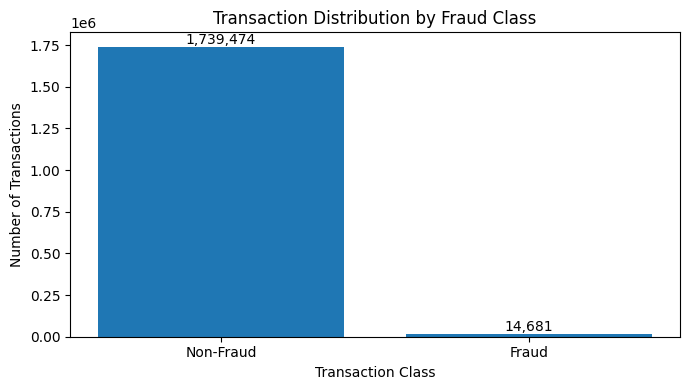

In [39]:
import matplotlib.pyplot as plt

fraud_plot_data = fraud_distribution.copy()

plt.figure(figsize=(7, 4))

plt.bar(
    fraud_plot_data["class_label"],
    fraud_plot_data["transaction_count"],
)

plt.title("Transaction Distribution by Fraud Class")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

for index, value in enumerate(
    fraud_plot_data["transaction_count"]
):
    plt.text(
        index,
        value,
        f"{value:,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

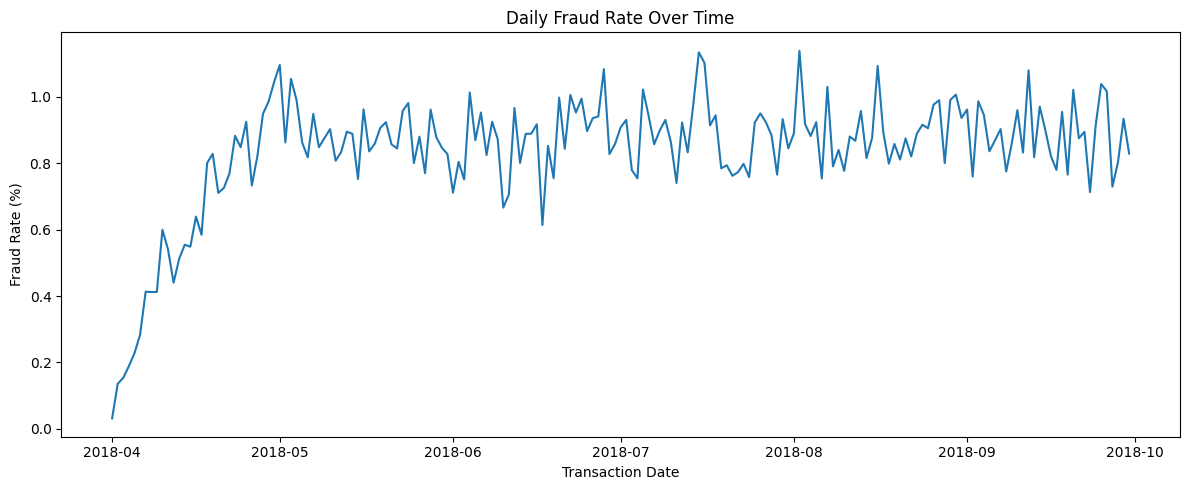

In [40]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_fraud_summary["transaction_date"],
    daily_fraud_summary["fraud_rate_percentage"],
)

plt.title("Daily Fraud Rate Over Time")
plt.xlabel("Transaction Date")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

## Fraud Distribution Checkpoint

The target analysis establishes the scale of class imbalance and examines whether fraud activity changes across the observation period.

These findings will guide the evaluation framework used in the modeling notebook. The next step is to inspect the available fraud scenarios and understand how fraudulent transactions are represented within the dataset.


In [41]:
fraud_distribution_checkpoint = pd.DataFrame(
    {
        "check": [
            "total_transactions",
            "fraud_transactions",
            "fraud_rate_percentage",
            "non_fraud_to_fraud_ratio",
            "observation_days",
        ],
        "value": [
            len(transactions),
            fraud_transactions,
            fraud_rate,
            class_imbalance_ratio,
            transactions["TX_DATETIME"]
            .dt.normalize()
            .nunique(),
        ],
    }
)

display(fraud_distribution_checkpoint)

,check,value
0,total_transactions,1.754155e+06
1,fraud_transactions,1.468100e+04
2,fraud_rate_percentage,8.369272e-01
3,non_fraud_to_fraud_ratio,1.184847e+02
4,observation_days,1.830000e+02


# 5. Fraud Scenario Analysis

The dataset contains a fraud scenario field in addition to the binary fraud target. This section examines the distribution of fraudulent transactions across the available scenarios.

The scenario variable is used for descriptive analysis and later error diagnostics. It is not treated as a predictive feature because it directly describes the fraud category associated with a transaction.


In [42]:
fraud_scenario_distribution = (
    transactions["TX_FRAUD_SCENARIO"]
    .value_counts()
    .rename_axis("fraud_scenario")
    .reset_index(name="transaction_count")
    .sort_values("fraud_scenario")
    .reset_index(drop=True)
)

fraud_scenario_distribution[
    "transaction_percentage"
] = (
    fraud_scenario_distribution["transaction_count"]
    / len(transactions)
    * 100
)

display(fraud_scenario_distribution)

,fraud_scenario,transaction_count,transaction_percentage
0,0,1739474,99.163073
1,1,973,0.055468
2,2,9077,0.517457
3,3,4631,0.264002


## Fraud Scenario Distribution Within Fraudulent Transactions

The overall scenario distribution is dominated by scenario `0`, which represents legitimate transactions. To understand the composition of actual fraud, the analysis is repeated using only transactions where `TX_FRAUD = 1`.


In [43]:
fraud_only_transactions = (
    transactions.loc[
        transactions["TX_FRAUD"] == 1
    ].copy()
)

fraud_only_scenario_distribution = (
    fraud_only_transactions["TX_FRAUD_SCENARIO"]
    .value_counts()
    .rename_axis("fraud_scenario")
    .reset_index(name="fraud_transaction_count")
    .sort_values("fraud_scenario")
    .reset_index(drop=True)
)

fraud_only_scenario_distribution[
    "fraud_percentage"
] = (
    fraud_only_scenario_distribution[
        "fraud_transaction_count"
    ]
    / len(fraud_only_transactions)
    * 100
)

display(fraud_only_scenario_distribution)

,fraud_scenario,fraud_transaction_count,fraud_percentage
0,1,973,6.627614
1,2,9077,61.828213
2,3,4631,31.544173


## Target and Scenario Consistency

The relationship between the binary fraud target and the fraud scenario field is validated to ensure that legitimate transactions are associated with scenario `0` and fraudulent transactions are represented by the fraud scenarios.


In [44]:
fraud_scenario_consistency = (
    pd.crosstab(
        transactions["TX_FRAUD"],
        transactions["TX_FRAUD_SCENARIO"],
    )
)

fraud_scenario_consistency.index.name = "TX_FRAUD"

display(fraud_scenario_consistency)

TX_FRAUD_SCENARIO,0,1,2,3
TX_FRAUD,,,,
0,1739474,0,0,0
1,0,973,9077,4631


In [45]:
non_fraud_with_non_zero_scenario = (
    (
        (transactions["TX_FRAUD"] == 0)
        & (
            transactions["TX_FRAUD_SCENARIO"] != 0
        )
    )
    .sum()
)

fraud_with_zero_scenario = (
    (
        (transactions["TX_FRAUD"] == 1)
        & (
            transactions["TX_FRAUD_SCENARIO"] == 0
        )
    )
    .sum()
)

scenario_consistency_checks = pd.DataFrame(
    {
        "check": [
            "non_fraud_with_non_zero_scenario",
            "fraud_with_zero_scenario",
        ],
        "count": [
            non_fraud_with_non_zero_scenario,
            fraud_with_zero_scenario,
        ],
        "passed": [
            non_fraud_with_non_zero_scenario == 0,
            fraud_with_zero_scenario == 0,
        ],
    }
)

display(scenario_consistency_checks)

,check,count,passed
0,non_fraud_with_non_zero_scenario,0,True
1,fraud_with_zero_scenario,0,True


## Transaction Amount by Fraud Scenario

Transaction amount patterns are compared across the fraud scenarios to identify whether different fraud mechanisms are associated with different transaction value distributions.

This is descriptive analysis only and does not modify the modeling dataset.


In [46]:
scenario_amount_summary = (
    transactions
    .groupby(
        "TX_FRAUD_SCENARIO",
        as_index=False,
    )["TX_AMOUNT"]
    .agg(
        transaction_count="count",
        mean_amount="mean",
        median_amount="median",
        min_amount="min",
        max_amount="max",
        total_amount="sum",
    )
    .sort_values("TX_FRAUD_SCENARIO")
    .reset_index(drop=True)
)

display(scenario_amount_summary)

,TX_FRAUD_SCENARIO,transaction_count,mean_amount,median_amount,min_amount,max_amount,total_amount
0,0,1739474,52.977907,44.49,0.00,219.98,92153692.32
1,1,973,235.317071,230.61,220.02,310.39,228963.51
2,2,9077,53.808108,46.02,0.02,234.69,488416.20
3,3,4631,260.915148,216.25,0.10,2628.00,1208298.05


In [47]:
fraud_scenario_amount_summary = (
    fraud_only_transactions
    .groupby(
        "TX_FRAUD_SCENARIO",
        as_index=False,
    )["TX_AMOUNT"]
    .agg(
        fraud_transaction_count="count",
        mean_amount="mean",
        median_amount="median",
        min_amount="min",
        max_amount="max",
        total_amount="sum",
    )
    .sort_values("TX_FRAUD_SCENARIO")
    .reset_index(drop=True)
)

display(fraud_scenario_amount_summary)

,TX_FRAUD_SCENARIO,fraud_transaction_count,mean_amount,median_amount,min_amount,max_amount,total_amount
0,1,973,235.317071,230.61,220.02,310.39,228963.51
1,2,9077,53.808108,46.02,0.02,234.69,488416.20
2,3,4631,260.915148,216.25,0.10,2628.00,1208298.05


## Fraud Scenario Activity Over Time

Fraud scenarios are also examined across the observation period. This helps determine whether each fraud type appears consistently or whether its activity is concentrated within particular time periods.

The results provide context for later chronological model validation.


In [48]:
monthly_scenario_distribution = (
    fraud_only_transactions.assign(
        transaction_month=(
            fraud_only_transactions["TX_DATETIME"]
            .dt.to_period("M")
            .astype(str)
        )
    )
    .groupby(
        [
            "transaction_month",
            "TX_FRAUD_SCENARIO",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "fraud_transaction_count",
        }
    )
)

monthly_scenario_distribution[
    "monthly_scenario_percentage"
] = (
    monthly_scenario_distribution[
        "fraud_transaction_count"
    ]
    / monthly_scenario_distribution.groupby(
        "transaction_month"
    )[
        "fraud_transaction_count"
    ].transform("sum")
    * 100
)

display(monthly_scenario_distribution)

,transaction_month,TX_FRAUD_SCENARIO,fraud_transaction_count,monthly_scenario_percentage
0,2018-04,1,168,9.870740
1,2018-04,2,931,54.700353
2,2018-04,3,603,35.428907
3,2018-05,1,141,5.342933
4,2018-05,2,1634,61.917393
5,2018-05,3,864,32.739674
6,2018-06,1,180,7.188498
7,2018-06,2,1596,63.738019
8,2018-06,3,728,29.073482
9,2018-07,1,171,6.526718


In [49]:
monthly_scenario_pivot = (
    monthly_scenario_distribution
    .pivot(
        index="transaction_month",
        columns="TX_FRAUD_SCENARIO",
        values="fraud_transaction_count",
    )
    .fillna(0)
    .reset_index()
)

monthly_scenario_pivot.columns.name = None

display(monthly_scenario_pivot)

,transaction_month,1,2,3
0,2018-04,168,931,603
1,2018-05,141,1634,864
2,2018-06,180,1596,728
3,2018-07,171,1588,861
4,2018-08,169,1692,808
5,2018-09,144,1636,767


## Modeling Decision

`TX_FRAUD_SCENARIO` will be retained for exploratory analysis and post-model error analysis but excluded from the predictive feature set.

The binary target `TX_FRAUD` remains the prediction target. Using the fraud scenario as an input feature could provide information that is directly related to the outcome and would not necessarily be available at prediction time.

This separation helps prevent target leakage and preserves a more realistic fraud prediction workflow.


In [50]:
scenario_modeling_decision = pd.DataFrame(
    {
        "column": [
            "TX_FRAUD",
            "TX_FRAUD_SCENARIO",
        ],
        "role": [
            "Binary prediction target",
            "Analysis and error diagnostic field",
        ],
        "included_as_model_feature": [
            False,
            False,
        ],
    }
)

display(scenario_modeling_decision)

,column,role,included_as_model_feature
0,TX_FRAUD,Binary prediction target,False
1,TX_FRAUD_SCENARIO,Analysis and error diagnostic field,False


## Fraud Scenario Checkpoint

The fraud scenarios have been analyzed as a descriptive layer separate from the binary prediction target.

The next stage will review the feature columns used by the project’s reusable preprocessing pipeline. This will establish the exact input structure before chronological data splitting and model-ready dataset preparation.


In [51]:
fraud_scenario_checkpoint = pd.DataFrame(
    {
        "check": [
            "fraud_scenarios_identified",
            "fraud_only_records",
            "non_fraud_scenario_consistency",
            "fraud_scenario_consistency",
            "scenario_used_as_model_feature",
        ],
        "value": [
            transactions["TX_FRAUD_SCENARIO"].nunique(),
            len(fraud_only_transactions),
            non_fraud_with_non_zero_scenario == 0,
            fraud_with_zero_scenario == 0,
            False,
        ],
    }
)

display(fraud_scenario_checkpoint)

,check,value
0,fraud_scenarios_identified,4
1,fraud_only_records,14681
2,non_fraud_scenario_consistency,True
3,fraud_scenario_consistency,True
4,scenario_used_as_model_feature,False


# Temporal and Entity-Level Transaction Analysis

The dataset spans 183 chronological days and contains repeated activity across customers and terminals. Before moving to feature engineering, this section examines transaction behavior over time and across entities.

The objective is to understand:

* daily transaction volume,
* daily fraud activity,
* customer-level transaction behavior,
* terminal-level transaction behavior,
* whether fraud activity is concentrated among a small number of entities.

This analysis supports the later use of a time-based validation strategy and helps identify the behavioral patterns that feature engineering should capture.


In [52]:
daily_activity = (
    transactions
    .assign(transaction_date=transactions["TX_DATETIME"].dt.date)
    .groupby("transaction_date")
    .agg(
        total_transactions=("TRANSACTION_ID", "count"),
        fraud_transactions=("TX_FRAUD", "sum"),
        transaction_amount=("TX_AMOUNT", "sum"),
    )
    .reset_index()
)

daily_activity["fraud_rate_percentage"] = (
    daily_activity["fraud_transactions"]
    / daily_activity["total_transactions"]
    * 100
)

daily_activity.head()

,transaction_date,total_transactions,fraud_transactions,transaction_amount,fraud_rate_percentage
0,2018-04-01,9488,3,505235.82,0.031619
1,2018-04-02,9583,13,504070.28,0.135657
2,2018-04-03,9747,15,524694.41,0.153894
3,2018-04-04,9530,18,507520.28,0.188877
4,2018-04-05,9651,22,515779.21,0.227956


In [53]:
daily_activity_summary = pd.DataFrame(
    {
        "metric": [
            "average_daily_transactions",
            "minimum_daily_transactions",
            "maximum_daily_transactions",
            "average_daily_fraud_transactions",
            "minimum_daily_fraud_transactions",
            "maximum_daily_fraud_transactions",
            "average_daily_fraud_rate_percentage",
        ],
        "value": [
            daily_activity["total_transactions"].mean(),
            daily_activity["total_transactions"].min(),
            daily_activity["total_transactions"].max(),
            daily_activity["fraud_transactions"].mean(),
            daily_activity["fraud_transactions"].min(),
            daily_activity["fraud_transactions"].max(),
            daily_activity["fraud_rate_percentage"].mean(),
        ],
    }
)

daily_activity_summary

,metric,value
0,average_daily_transactions,9585.546448
1,minimum_daily_transactions,9285.000000
2,maximum_daily_transactions,9789.000000
3,average_daily_fraud_transactions,80.224044
4,minimum_daily_fraud_transactions,3.000000
5,maximum_daily_fraud_transactions,110.000000
6,average_daily_fraud_rate_percentage,0.836896


In [54]:
customer_activity = (
    transactions
    .groupby("CUSTOMER_ID")
    .agg(
        transaction_count=("TRANSACTION_ID", "count"),
        fraud_transaction_count=("TX_FRAUD", "sum"),
        total_transaction_amount=("TX_AMOUNT", "sum"),
        average_transaction_amount=("TX_AMOUNT", "mean"),
    )
    .reset_index()
)

customer_activity["fraud_rate_percentage"] = (
    customer_activity["fraud_transaction_count"]
    / customer_activity["transaction_count"]
    * 100
)

customer_activity.describe()

,CUSTOMER_ID,transaction_count,fraud_transaction_count,total_transaction_amount,average_transaction_amount,fraud_rate_percentage
count,4990.000000,4990.000000,4990.000000,4990.000000,4990.000000,4990.000000
mean,2499.388176,351.534068,2.942084,18853.581178,53.750436,0.836360
std,1444.195201,205.106511,4.385838,16021.294178,29.060778,1.187876
min,0.000000,1.000000,0.000000,22.410000,4.943002,0.000000
25%,1248.250000,174.000000,0.000000,5491.040000,28.597279,0.000000
50%,2499.500000,347.000000,2.000000,14323.370000,53.618617,0.485437
75%,3751.750000,531.000000,4.000000,28174.085000,78.665555,1.086957
max,4999.000000,767.000000,45.000000,78050.650000,136.922000,20.000000


In [55]:
terminal_activity = (
    transactions
    .groupby("TERMINAL_ID")
    .agg(
        transaction_count=("TRANSACTION_ID", "count"),
        fraud_transaction_count=("TX_FRAUD", "sum"),
        total_transaction_amount=("TX_AMOUNT", "sum"),
        average_transaction_amount=("TX_AMOUNT", "mean"),
    )
    .reset_index()
)

terminal_activity["fraud_rate_percentage"] = (
    terminal_activity["fraud_transaction_count"]
    / terminal_activity["transaction_count"]
    * 100
)

terminal_activity.describe()

,TERMINAL_ID,transaction_count,fraud_transaction_count,total_transaction_amount,average_transaction_amount,fraud_rate_percentage
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,175.415500,1.468100,9407.937008,53.666434,0.829229
std,2886.89568,39.170273,5.144651,2346.747018,6.416164,2.827738
min,0.00000,47.000000,0.000000,2700.210000,33.575385,0.000000
25%,2499.75000,148.000000,0.000000,7776.582500,49.164105,0.000000
50%,4999.50000,171.000000,0.000000,9254.915000,53.610478,0.000000
75%,7499.25000,199.250000,1.000000,10839.870000,58.018743,0.613497
max,9999.00000,376.000000,85.000000,21904.740000,78.279231,35.643564


In [56]:
entity_activity_checks = pd.DataFrame(
    [
        {
            "entity": "CUSTOMER_ID",
            "unique_entities": customer_activity.shape[0],
            "minimum_transactions": customer_activity["transaction_count"].min(),
            "maximum_transactions": customer_activity["transaction_count"].max(),
            "average_transactions": customer_activity["transaction_count"].mean(),
            "entities_with_fraud": (
                customer_activity["fraud_transaction_count"] > 0
            ).sum(),
        },
        {
            "entity": "TERMINAL_ID",
            "unique_entities": terminal_activity.shape[0],
            "minimum_transactions": terminal_activity["transaction_count"].min(),
            "maximum_transactions": terminal_activity["transaction_count"].max(),
            "average_transactions": terminal_activity["transaction_count"].mean(),
            "entities_with_fraud": (
                terminal_activity["fraud_transaction_count"] > 0
            ).sum(),
        },
    ]
)

entity_activity_checks

,entity,unique_entities,minimum_transactions,maximum_transactions,average_transactions,entities_with_fraud
0,CUSTOMER_ID,4990,1,767,351.534068,3472
1,TERMINAL_ID,10000,47,376,175.415500,4266


# Interpretation

The dataset contains repeated customer and terminal interactions across the full observation period. Transaction behavior therefore has both temporal and entity-level structure.

The presence of repeated transactions from the same customers and terminals supports the use of behavioral features such as historical transaction counts, transaction amount patterns, and recent activity.

However, this structure also introduces an important modeling constraint: features based on historical behavior must be generated using only information available at the time of prediction. Future observations must not influence earlier transactions.

The next stage will therefore inspect the available modeling features and apply the project’s existing reusable preprocessing and time-based splitting components.


## Entity and Temporal Coverage Analysis

Fraud detection data contains repeated customers and terminals across time. Before creating the chronological train, validation, and test periods, the analysis checks how entities are distributed throughout the dataset.

This helps distinguish two practical conditions:

- **Recurring entities:** customers or terminals already observed in earlier periods.
- **New entities:** customers or terminals appearing for the first time in later periods.

The dataset will later be split chronologically because fraud detection is evaluated as a forward-looking prediction problem. Entity overlap is analyzed here only to understand the structure of that temporal deployment setting.

In [57]:
entity_columns = ["CUSTOMER_ID", "TERMINAL_ID"]

entity_temporal_summary = []

for entity_column in entity_columns:
    entity_summary = (
        transactions.groupby(entity_column)
        .agg(
            first_observation=("TX_DATETIME", "min"),
            last_observation=("TX_DATETIME", "max"),
            transaction_count=("TRANSACTION_ID", "count"),
            fraud_transaction_count=("TX_FRAUD", "sum"),
        )
        .reset_index()
    )

    entity_summary["entity_type"] = entity_column
    entity_summary["observation_span_days"] = (
        entity_summary["last_observation"]
        - entity_summary["first_observation"]
    ).dt.days

    entity_temporal_summary.append(entity_summary)

entity_temporal_summary = pd.concat(
    entity_temporal_summary,
    ignore_index=True,
)

entity_temporal_summary.head()

,CUSTOMER_ID,first_observation,last_observation,transaction_count,fraud_transaction_count,entity_type,observation_span_days,TERMINAL_ID
0,0.0,2018-04-01 07:19:05,2018-09-30 15:11:37,384,1,CUSTOMER_ID,182,NaN
1,1.0,2018-04-01 05:51:21,2018-09-30 14:20:20,661,23,CUSTOMER_ID,182,NaN
2,2.0,2018-04-01 00:07:56,2018-09-30 21:23:21,338,2,CUSTOMER_ID,182,NaN
3,3.0,2018-04-02 17:26:51,2018-09-21 22:32:18,55,0,CUSTOMER_ID,172,NaN
4,4.0,2018-04-01 05:34:23,2018-09-30 10:33:40,641,0,CUSTOMER_ID,182,NaN


In [58]:
entity_coverage_summary = (
    entity_temporal_summary.groupby("entity_type")
    .agg(
        unique_entities=("observation_span_days", "count"),
        average_first_observation=("first_observation", "mean"),
        average_last_observation=("last_observation", "mean"),
        minimum_observation_span_days=("observation_span_days", "min"),
        maximum_observation_span_days=("observation_span_days", "max"),
        average_observation_span_days=("observation_span_days", "mean"),
        entities_with_fraud=("fraud_transaction_count", lambda x: (x > 0).sum()),
    )
    .reset_index()
)

entity_coverage_summary

,entity_type,unique_entities,average_first_observation,average_last_observation,minimum_observation_span_days,maximum_observation_span_days,average_observation_span_days,entities_with_fraud
0,CUSTOMER_ID,4990,2018-04-02 14:16:48.705611264,2018-09-29 07:07:40.148697344,0,182,179.258116,3472
1,TERMINAL_ID,10000,2018-04-02 03:01:14.312800000,2018-09-29 20:59:35.002300160,166,182,180.285400,4266


### Interpretation

The entity coverage analysis shows whether customers and terminals are observed repeatedly across the six-month transaction period.

Repeated entities are important for realistic fraud modeling because historical customer and terminal behavior can support feature engineering. However, the evaluation strategy must still respect time order.

The next step is therefore to define chronological train, validation, and test periods using the reusable project split function. This ensures that all future transactions remain unseen during model development.

## Chronological Train, Validation, and Test Split

Fraud detection is a time-dependent prediction problem. A random split could allow the model to learn from transactions occurring after the records it is supposed to predict.

To prevent this type of temporal leakage, the dataset is divided chronologically:

- **Training period:** used for model learning.
- **Validation period:** used for model comparison and threshold selection.
- **Test period:** reserved for final evaluation.

The reusable `split_by_time` function is used so that the notebook follows the same data-splitting logic as the project codebase.

In [59]:
split_result = split_by_time(transactions)

split_result

(         TRANSACTION_ID         TX_DATETIME CUSTOMER_ID TERMINAL_ID  \
 0                     0 2018-04-01 00:00:31         596        3156   
 1                     1 2018-04-01 00:02:10        4961        3412   
 2                     2 2018-04-01 00:07:56           2        1365   
 3                     3 2018-04-01 00:09:29        4128        8737   
 4                     4 2018-04-01 00:10:34         927        9906   
 ...                 ...                 ...         ...         ...   
 1169718         1169718 2018-07-31 23:55:06        4219         557   
 1169719         1169719 2018-07-31 23:56:10        1044        4831   
 1169720         1169720 2018-07-31 23:57:42        1182        9765   
 1169721         1169721 2018-07-31 23:58:14        3802        2777   
 1169722         1169722 2018-07-31 23:58:53        4582        8107   
 
          TX_AMOUNT TX_TIME_SECONDS TX_TIME_DAYS  TX_FRAUD  TX_FRAUD_SCENARIO  
 0            57.16              31            0      

# Chronological Dataset Split

The reusable `split_by_time` function has divided the transaction dataset into three chronological periods.

The splits are used for different purposes:

* **Training:** model learning and feature preparation.
* **Validation:** model comparison and operating-threshold selection.
* **Test:** final evaluation of the selected solution.

The split is validated explicitly to confirm that transaction records remain in chronological order and that no record appears in more than one dataset.


In [60]:
train_transactions, validation_transactions, test_transactions = split_result

split_sizes = pd.DataFrame(
    {
        "split": ["Train", "Validation", "Test"],
        "records": [
            train_transactions.shape[0],
            validation_transactions.shape[0],
            test_transactions.shape[0],
        ],
        "percentage_of_dataset": [
            train_transactions.shape[0] / transactions.shape[0] * 100,
            validation_transactions.shape[0] / transactions.shape[0] * 100,
            test_transactions.shape[0] / transactions.shape[0] * 100,
        ],
    }
)

split_sizes

,split,records,percentage_of_dataset
0,Train,1169723,66.682990
1,Validation,296559,16.906089
2,Test,287873,16.410921


In [61]:
temporal_split_summary = pd.DataFrame(
    [
        {
            "split": "Train",
            "records": train_transactions.shape[0],
            "start_datetime": train_transactions["TX_DATETIME"].min(),
            "end_datetime": train_transactions["TX_DATETIME"].max(),
            "duration_days": (
                train_transactions["TX_DATETIME"].max()
                - train_transactions["TX_DATETIME"].min()
            ).days,
        },
        {
            "split": "Validation",
            "records": validation_transactions.shape[0],
            "start_datetime": validation_transactions["TX_DATETIME"].min(),
            "end_datetime": validation_transactions["TX_DATETIME"].max(),
            "duration_days": (
                validation_transactions["TX_DATETIME"].max()
                - validation_transactions["TX_DATETIME"].min()
            ).days,
        },
        {
            "split": "Test",
            "records": test_transactions.shape[0],
            "start_datetime": test_transactions["TX_DATETIME"].min(),
            "end_datetime": test_transactions["TX_DATETIME"].max(),
            "duration_days": (
                test_transactions["TX_DATETIME"].max()
                - test_transactions["TX_DATETIME"].min()
            ).days,
        },
    ]
)

temporal_split_summary

,split,records,start_datetime,end_datetime,duration_days
0,Train,1169723,2018-04-01 00:00:31,2018-07-31 23:58:53,121
1,Validation,296559,2018-08-01 00:00:19,2018-08-31 23:59:07,30
2,Test,287873,2018-09-01 00:01:18,2018-09-30 23:59:57,29


In [62]:
split_integrity_checks = pd.DataFrame(
    [
        {
            "check": "train_records_present",
            "result": train_transactions.shape[0] > 0,
        },
        {
            "check": "validation_records_present",
            "result": validation_transactions.shape[0] > 0,
        },
        {
            "check": "test_records_present",
            "result": test_transactions.shape[0] > 0,
        },
        {
            "check": "train_before_validation",
            "result": (
                train_transactions["TX_DATETIME"].max()
                < validation_transactions["TX_DATETIME"].min()
            ),
        },
        {
            "check": "validation_before_test",
            "result": (
                validation_transactions["TX_DATETIME"].max()
                < test_transactions["TX_DATETIME"].min()
            ),
        },
        {
            "check": "total_records_preserved",
            "result": (
                train_transactions.shape[0]
                + validation_transactions.shape[0]
                + test_transactions.shape[0]
                == transactions.shape[0]
            ),
        },
        {
            "check": "transaction_ids_unique_across_splits",
            "result": (
                pd.concat(
                    [
                        train_transactions["TRANSACTION_ID"],
                        validation_transactions["TRANSACTION_ID"],
                        test_transactions["TRANSACTION_ID"],
                    ]
                ).nunique()
                == transactions.shape[0]
            ),
        },
    ]
)

split_integrity_checks

,check,result
0,train_records_present,True
1,validation_records_present,True
2,test_records_present,True
3,train_before_validation,True
4,validation_before_test,True
5,total_records_preserved,True
6,transaction_ids_unique_across_splits,True


In [63]:
split_fraud_summary = pd.DataFrame(
    [
        {
            "split": "Train",
            "total_transactions": train_transactions.shape[0],
            "fraud_transactions": train_transactions["TX_FRAUD"].sum(),
            "fraud_rate_percentage": (
                train_transactions["TX_FRAUD"].mean() * 100
            ),
        },
        {
            "split": "Validation",
            "total_transactions": validation_transactions.shape[0],
            "fraud_transactions": validation_transactions["TX_FRAUD"].sum(),
            "fraud_rate_percentage": (
                validation_transactions["TX_FRAUD"].mean() * 100
            ),
        },
        {
            "split": "Test",
            "total_transactions": test_transactions.shape[0],
            "fraud_transactions": test_transactions["TX_FRAUD"].sum(),
            "fraud_rate_percentage": (
                test_transactions["TX_FRAUD"].mean() * 100
            ),
        },
    ]
)

split_fraud_summary

,split,total_transactions,fraud_transactions,fraud_rate_percentage
0,Train,1169723,9465,0.809166
1,Validation,296559,2669,0.899990
2,Test,287873,2547,0.884765


In [64]:
split_verification_summary = pd.DataFrame(
    [
        {
            "check": "train_validation_test_created",
            "result": True,
        },
        {
            "check": "chronological_order_preserved",
            "result": (
                (
                    train_transactions["TX_DATETIME"].max()
                    < validation_transactions["TX_DATETIME"].min()
                )
                and (
                    validation_transactions["TX_DATETIME"].max()
                    < test_transactions["TX_DATETIME"].min()
                )
            ),
        },
        {
            "check": "all_records_preserved",
            "result": (
                train_transactions.shape[0]
                + validation_transactions.shape[0]
                + test_transactions.shape[0]
                == transactions.shape[0]
            ),
        },
        {
            "check": "no_duplicate_transaction_ids",
            "result": (
                pd.concat(
                    [
                        train_transactions,
                        validation_transactions,
                        test_transactions,
                    ]
                )["TRANSACTION_ID"].nunique()
                == transactions.shape[0]
            ),
        },
    ]
)

split_verification_summary

,check,result
0,train_validation_test_created,True
1,chronological_order_preserved,True
2,all_records_preserved,True
3,no_duplicate_transaction_ids,True


# Split Verification

The reusable chronological split has now been converted into separate training, validation, and test datasets.

The validation checks confirm that:

* all three datasets contain records,
* time order is preserved,
* training data occurs before validation data,
* validation data occurs before test data,
* the original record count is preserved,
* transaction records do not overlap across splits.

This establishes the evaluation framework for the remaining modeling workflow. All feature preparation and model-development decisions will now be based on these chronological datasets rather than a random data split.


# Feature Engineering

The raw transaction dataset has passed the initial quality checks and the chronological split strategy has been validated. Before preparing model inputs, behavioural features must be generated from the transaction history.

The project already contains a reusable feature-engineering pipeline. This pipeline creates the approved temporal, customer-level, and terminal-level features while using information available before the current transaction.

The complete feature dataset will be created first and then split chronologically. This ensures that the model-development notebook receives datasets containing the full approved feature schema.


In [65]:
from app.features.pipeline import build_feature_dataset

print(
    "Reusable feature engineering pipeline imported successfully."
)

Reusable feature engineering pipeline imported successfully.


### Leakage-Safe Feature Engineering

The fraud model uses temporal, customer-behaviour, and terminal-behaviour features generated through the reusable application pipeline.

Historical features are calculated using information from transactions that occurred before the current transaction. Customer and terminal activity windows are also evaluated before the current transaction is added to the corresponding history.

This prevents the current transaction's own outcome from influencing its model inputs.

The feature pipeline is applied chronologically across the transaction history so that behavioural features retain the historical context required for realistic fraud detection. The resulting feature dataset is then divided using the project's predefined chronological train, validation, and test boundaries.

The terminal fraud-history features require particular care because they depend on previously observed fraud outcomes. Therefore, their interpretation follows the project's sequential scoring assumption: a previous transaction can contribute to later historical fraud behaviour only once its outcome is considered available to the system.

This distinction is important because preventing current-row target leakage is different from defining when historical labels become available during production scoring.


In [66]:
feature_transactions = build_feature_dataset(
    transactions
)

print(
    "Feature dataset created successfully."
)

print(
    f"Feature dataset shape: {feature_transactions.shape}"
)

Feature dataset created successfully.
Feature dataset shape: (1754155, 31)


In [67]:
feature_summary = pd.DataFrame(
    {
        "dataset": [
            "Raw transactions",
            "Feature dataset",
        ],
        "records": [
            len(transactions),
            len(feature_transactions),
        ],
        "columns": [
            transactions.shape[1],
            feature_transactions.shape[1],
        ],
    }
)

feature_summary

,dataset,records,columns
0,Raw transactions,1754155,9
1,Feature dataset,1754155,31


## Model Feature Availability Check

The generated dataset is checked against the approved project feature schema before the chronological split is recreated. This confirms that all required model features are present and prevents incomplete datasets from being passed to the modeling workflow.

The feature schema is defined centrally in the project so that Notebook 1, Notebook 2, and the application use the same model inputs.


In [68]:
feature_availability = pd.DataFrame(
    {
        "model_feature": MODEL_FEATURES,
        "available": [
            feature in feature_transactions.columns
            for feature in MODEL_FEATURES
        ],
    }
)

feature_availability

,model_feature,available
0,TX_AMOUNT,True
1,hour_of_day,True
2,day_of_week,True
3,is_weekend,True
4,customer_tx_count,True
5,customer_avg_amount,True
6,customer_max_amount,True
7,customer_amount_std,True
8,time_since_customer_tx,True
9,customer_amount_deviation,True


In [69]:
missing_model_features = feature_availability.loc[
    ~feature_availability["available"],
    "model_feature",
].tolist()

feature_validation = pd.DataFrame(
    {
        "check": [
            "total_required_model_features",
            "available_model_features",
            "missing_model_features",
            "all_model_features_available",
        ],
        "value": [
            len(MODEL_FEATURES),
            int(feature_availability["available"].sum()),
            len(missing_model_features),
            len(missing_model_features) == 0,
        ],
    }
)

feature_validation

,check,value
0,total_required_model_features,23
1,available_model_features,23
2,missing_model_features,0
3,all_model_features_available,True


In [70]:
engineered_features = [
    column
    for column in feature_transactions.columns
    if column not in transactions.columns
]

pd.DataFrame(
    {
        "engineered_feature": engineered_features
    }
)

,engineered_feature
0,hour_of_day
1,day_of_week
2,is_weekend
3,customer_tx_count
4,customer_avg_amount
5,customer_max_amount
6,customer_amount_std
7,time_since_customer_tx
8,customer_amount_deviation
9,customer_amount_ratio


### Chronological Split of Final Feature Dataset

The engineered transaction dataset is divided according to the predefined chronological boundaries used by the project.

* **Training:** April–July 2018
* **Validation:** August 2018
* **Test:** September 2018

The chronological ordering is preserved throughout the workflow so that later transactions are not used to construct features for earlier transactions.

The training set is used for model fitting, the validation set is used for model comparison and decision selection, and the September test period is reserved for final evaluation after model development is complete.

The same split boundaries are implemented by the reusable `split_by_time()` function used by the application.


In [71]:
train_features, validation_features, test_features = split_by_time(
    feature_transactions
)

print("Engineered dataset split successfully.")

split_summary = pd.DataFrame(
    {
        "split": ["Train", "Validation", "Test"],
        "records": [
            len(train_features),
            len(validation_features),
            len(test_features),
        ],
        "percentage_of_dataset": [
            len(train_features) / len(feature_transactions) * 100,
            len(validation_features) / len(feature_transactions) * 100,
            len(test_features) / len(feature_transactions) * 100,
        ],
    }
)

split_summary

Engineered dataset split successfully.


,split,records,percentage_of_dataset
0,Train,1169723,66.682990
1,Validation,296559,16.906089
2,Test,287873,16.410921


### Engineered Dataset Split Validation

The chronological boundaries are validated again after feature creation.

This confirms that the temporal order, record counts, and transaction separation remain intact in the engineered datasets before model data is prepared.

In [72]:
feature_split_boundaries = pd.DataFrame(
    {
        "split": ["Train", "Validation", "Test"],
        "start_datetime": [
            train_features["TX_DATETIME"].min(),
            validation_features["TX_DATETIME"].min(),
            test_features["TX_DATETIME"].min(),
        ],
        "end_datetime": [
            train_features["TX_DATETIME"].max(),
            validation_features["TX_DATETIME"].max(),
            test_features["TX_DATETIME"].max(),
        ],
    }
)

feature_split_checks = pd.DataFrame(
    {
        "check": [
            "train_before_validation",
            "validation_before_test",
            "all_records_preserved",
            "no_duplicate_transaction_ids",
        ],
        "result": [
            train_features["TX_DATETIME"].max()
            < validation_features["TX_DATETIME"].min(),
            validation_features["TX_DATETIME"].max()
            < test_features["TX_DATETIME"].min(),
            (
                len(train_features)
                + len(validation_features)
                + len(test_features)
            )
            == len(feature_transactions),
            (
                len(
                    set(train_features["TRANSACTION_ID"])
                    | set(validation_features["TRANSACTION_ID"])
                    | set(test_features["TRANSACTION_ID"])
                )
                == len(feature_transactions)
            ),
        ],
    }
)

display(feature_split_boundaries)
display(feature_split_checks)

,split,start_datetime,end_datetime
0,Train,2018-04-01 00:00:31,2018-07-31 23:58:53
1,Validation,2018-08-01 00:00:19,2018-08-31 23:59:07
2,Test,2018-09-01 00:01:18,2018-09-30 23:59:57


,check,result
0,train_before_validation,True
1,validation_before_test,True
2,all_records_preserved,True
3,no_duplicate_transaction_ids,True


## Preparing Model Training, Validation, and Test Data

The engineered datasets are converted into model-ready feature matrices and target vectors using the reusable `prepare_model_data()` function.

The function uses the project's predefined feature configuration to ensure that training, validation, and test data contain the same model inputs.

The prediction target is `TX_FRAUD`.

Identifier, datetime, target, and diagnostic columns are not passed directly as model features.

In [73]:
X_train, y_train = prepare_model_data(train_features)

X_validation, y_validation = prepare_model_data(
    validation_features
)

X_test, y_test = prepare_model_data(test_features)

print("Model data prepared successfully.")

Model data prepared successfully.


### Model Data Validation

The prepared datasets are checked to confirm that:

- all predefined model features are present
- training, validation, and test feature counts are consistent
- target values remain binary
- feature and target record counts match

This provides a final data interface check before model training begins.

In [74]:
model_data_summary = pd.DataFrame(
    {
        "dataset": ["Train", "Validation", "Test"],
        "feature_rows": [
            X_train.shape[0],
            X_validation.shape[0],
            X_test.shape[0],
        ],
        "feature_columns": [
            X_train.shape[1],
            X_validation.shape[1],
            X_test.shape[1],
        ],
        "target_records": [
            len(y_train),
            len(y_validation),
            len(y_test),
        ],
    }
)

model_data_checks = pd.DataFrame(
    {
        "check": [
            "all_train_features_match_configuration",
            "all_validation_features_match_configuration",
            "all_test_features_match_configuration",
            "consistent_feature_columns",
            "train_feature_target_alignment",
            "validation_feature_target_alignment",
            "test_feature_target_alignment",
            "train_target_is_binary",
            "validation_target_is_binary",
            "test_target_is_binary",
        ],
        "result": [
            list(X_train.columns) == MODEL_FEATURES,
            list(X_validation.columns) == MODEL_FEATURES,
            list(X_test.columns) == MODEL_FEATURES,
            (
                list(X_train.columns)
                == list(X_validation.columns)
                == list(X_test.columns)
            ),
            len(X_train) == len(y_train),
            len(X_validation) == len(y_validation),
            len(X_test) == len(y_test),
            set(y_train.unique()) <= {0, 1},
            set(y_validation.unique()) <= {0, 1},
            set(y_test.unique()) <= {0, 1},
        ],
    }
)

display(model_data_summary)
display(model_data_checks)

,dataset,feature_rows,feature_columns,target_records
0,Train,1169723,23,1169723
1,Validation,296559,23,296559
2,Test,287873,23,287873


,check,result
0,all_train_features_match_configuration,True
1,all_validation_features_match_configuration,True
2,all_test_features_match_configuration,True
3,consistent_feature_columns,True
4,train_feature_target_alignment,True
5,validation_feature_target_alignment,True
6,test_feature_target_alignment,True
7,train_target_is_binary,True
8,validation_target_is_binary,True
9,test_target_is_binary,True


## Model-Ready Dataset Quality Check

Before completing the feature engineering notebook, the model-ready datasets are checked for numerical completeness and consistency.

The validation focuses on the final feature matrices used by the modeling workflow. Training, validation, and test datasets must contain the same feature schema, valid numerical values, and no missing or infinite values.

The test dataset remains reserved for final model evaluation and is not used for model selection or threshold optimization.

In [75]:
model_ready_datasets = {
    "Train": (X_train, y_train),
    "Validation": (X_validation, y_validation),
    "Test": (X_test, y_test),
}

model_data_quality_rows = []

for dataset_name, (X, y) in model_ready_datasets.items():
    values = X.to_numpy(dtype=float)

    model_data_quality_rows.append(
        {
            "dataset": dataset_name,
            "records": len(X),
            "features": X.shape[1],
            "missing_values": int(X.isna().sum().sum()),
            "infinite_values": int(
                np.isinf(values).sum()
            ),
            "feature_columns_numeric": bool(
                all(
                    pd.api.types.is_numeric_dtype(
                        dtype
                    )
                    for dtype in X.dtypes
                )
            ),
            "binary_target": bool(
                set(y.unique()) <= {0, 1}
            ),
        }
    )

model_data_quality = pd.DataFrame(
    model_data_quality_rows
)

model_data_quality

,dataset,records,features,missing_values,infinite_values,feature_columns_numeric,binary_target
0,Train,1169723,23,0,0,True,True
1,Validation,296559,23,0,0,True,True
2,Test,287873,23,0,0,True,True


### Train, Validation, and Test Feature Distribution Summary

The mean and standard deviation of each approved model feature are compared across the chronological datasets.

This provides a descriptive sanity check for major differences in feature scale or behaviour between the training, validation, and test periods.

Because the datasets are separated chronologically, some variation across periods is expected. These statistics are used only as exploratory diagnostics and are not used for model selection, threshold optimization, or formal statistical drift detection.

Formal model comparison and decision-making are performed in Notebook 2 using the validation dataset.


In [76]:
feature_distribution_summary = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "train_mean": X_train.mean().values,
        "validation_mean": X_validation.mean().values,
        "test_mean": X_test.mean().values,
        "train_std": X_train.std().values,
        "validation_std": X_validation.std().values,
        "test_std": X_test.std().values,
    }
)

feature_distribution_summary

,feature,train_mean,validation_mean,test_mean,train_std,validation_std,test_std
0,TX_AMOUNT,53.621034,53.691091,53.617523,42.107868,42.549625,42.977165
1,hour_of_day,11.499497,11.504709,11.500134,5.055441,5.063909,5.058860
2,day_of_week,2.982482,3.001018,3.171874,2.020980,1.919377,2.035605
3,is_weekend,0.286748,0.258589,0.334460,0.452243,0.437860,0.471802
4,customer_tx_count,156.743840,353.325537,431.638695,112.010144,130.252397,158.047645
5,customer_avg_amount,53.320967,53.669023,53.597701,29.245941,28.766484,28.785815
6,customer_max_amount,127.019727,151.648566,158.716661,98.739248,128.895579,141.690830
7,customer_amount_std,25.357924,26.353829,26.472894,16.426861,16.155474,16.157740
8,time_since_customer_tx,43789.066447,44897.419927,44951.011637,81705.587221,91704.508032,102308.347813
9,customer_amount_deviation,0.073217,0.021152,0.019611,31.097686,31.537095,32.063352


## Final Data Separation Check

The final chronological datasets are checked to confirm that the training, validation, and test periods remain separate after feature engineering.

The model target is excluded from the feature matrices, and the fraud scenario column is retained only for analysis and diagnostics rather than model training.

This establishes the final data boundary before the modeling notebook begins.

In [77]:
final_data_checks = pd.DataFrame(
    {
        "check": [
            "train_validation_transaction_ids_do_not_overlap",
            "validation_test_transaction_ids_do_not_overlap",
            "train_test_transaction_ids_do_not_overlap",
            "target_not_in_model_features",
            "fraud_scenario_not_in_model_features",
            "feature_schema_matches_model_configuration",
            "all_model_data_quality_checks_pass",
        ],
        "result": [
            set(
                train_features["TRANSACTION_ID"]
            ).isdisjoint(
                validation_features["TRANSACTION_ID"]
            ),
            set(
                validation_features["TRANSACTION_ID"]
            ).isdisjoint(
                test_features["TRANSACTION_ID"]
            ),
            set(
                train_features["TRANSACTION_ID"]
            ).isdisjoint(
                test_features["TRANSACTION_ID"]
            ),
            TARGET_COLUMN not in X_train.columns,
            "TX_FRAUD_SCENARIO"
            not in X_train.columns,
            list(X_train.columns)
            == MODEL_FEATURES,
            (
                model_data_quality[
                    "missing_values"
                ].eq(0).all()
                and model_data_quality[
                    "infinite_values"
                ].eq(0).all()
                and model_data_quality[
                    "feature_columns_numeric"
                ].all()
                and model_data_quality[
                    "binary_target"
                ].all()
            ),
        ],
    }
)

final_data_checks

,check,result
0,train_validation_transaction_ids_do_not_overlap,True
1,validation_test_transaction_ids_do_not_overlap,True
2,train_test_transaction_ids_do_not_overlap,True
3,target_not_in_model_features,True
4,fraud_scenario_not_in_model_features,True
5,feature_schema_matches_model_configuration,True
6,all_model_data_quality_checks_pass,True


## Processed Data Storage

The final engineered datasets are stored in the project's processed data directory.

The directory is created from the detected project root so that the notebook can be executed from the `notebooks` folder without relying on the current working directory.

In [78]:
from pathlib import Path

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "Processed data directory:",
    PROCESSED_DATA_DIR
)

print(
    "Directory exists:",
    PROCESSED_DATA_DIR.exists()
)

Processed data directory: c:\AI\fraud-risk-intelligence-platform\data\processed
Directory exists: True


### Processed Dataset Persistence

The finalized chronological datasets are persisted in Parquet format for reuse by the modeling workflow.

Parquet is used because it provides efficient storage, preserves the prepared data types, and supports fast loading of large tabular datasets.

The following artifacts are saved:

* `train_features.parquet`
* `validation_features.parquet`
* `test_features.parquet`

These files contain the finalized feature datasets produced by Notebook 1 and serve as the direct input to Notebook 2.

Notebook 2 therefore begins from the persisted modeling datasets rather than repeating the raw-data loading and feature-engineering workflow.


In [79]:
PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

train_features_path = (
    PROCESSED_DATA_DIR
    / "train_features.parquet"
)

validation_features_path = (
    PROCESSED_DATA_DIR
    / "validation_features.parquet"
)

test_features_path = (
    PROCESSED_DATA_DIR
    / "test_features.parquet"
)

train_features.to_parquet(
    train_features_path,
    index=False,
)

validation_features.to_parquet(
    validation_features_path,
    index=False,
)

test_features.to_parquet(
    test_features_path,
    index=False,
)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


### Persistence Verification

The saved datasets are verified after persistence to confirm that all files exist and preserve the expected number of records and columns.

In [80]:
processed_files = {
    "Train": train_features_path,
    "Validation": validation_features_path,
    "Test": test_features_path,
}

persistence_rows = []

for dataset_name, file_path in (
    processed_files.items()
):
    saved_dataset = pd.read_parquet(
        file_path
    )

    persistence_rows.append(
        {
            "dataset": dataset_name,
            "file_exists": file_path.exists(),
            "records": len(saved_dataset),
            "columns": saved_dataset.shape[1],
            "path": str(file_path),
        }
    )

persistence_check = pd.DataFrame(
    persistence_rows
)

persistence_check

,dataset,file_exists,records,columns,path
0,Train,True,1169723,31,c:\AI\fraud-risk-intelligence-platform\data\pr...
1,Validation,True,296559,31,c:\AI\fraud-risk-intelligence-platform\data\pr...
2,Test,True,287873,31,c:\AI\fraud-risk-intelligence-platform\data\pr...


### Notebook 1 Summary

This notebook establishes the finalized data and feature foundation for the Fraud Risk Intelligence Platform.

Completed workflow:

* Loaded the raw transaction dataset through reusable project components.
* Validated data quality, identifiers, target integrity, and chronological ordering.
* Quantified fraud prevalence and class imbalance.
* Analysed fraud scenarios as a descriptive and diagnostic layer.
* Examined temporal and entity-level transaction behaviour.
* Generated temporal, customer-level, and terminal-level behavioural features through the reusable feature pipeline.
* Verified the centrally configured 23-feature model schema.
* Created chronological training, validation, and test datasets.
* Prepared and validated the model-ready feature matrices.
* Confirmed dataset separation, numerical quality, and feature consistency.
* Persisted the finalized engineered datasets for reproducible model development.

The feature pipeline uses prior transaction history for behavioural features, including historical terminal fraud signals. These features therefore follow the project's sequential scoring assumption regarding when previous transaction outcomes become available.

The persisted datasets produced by this notebook are the direct inputs to Notebook 2, where model development, validation, threshold analysis, model selection, and final evaluation are performed.


In [81]:
notebook_1_summary = pd.DataFrame(
    {
        "component": [
            "Raw dataset",
            "Final feature dataset",
            "Model features",
            "Training records",
            "Validation records",
            "Test records",
            "Chronological separation",
            "Model-ready data",
            "Processed datasets saved",
        ],
        "status": [
            "Complete",
            "Complete",
            f"{len(MODEL_FEATURES)} available",
            len(X_train),
            len(X_validation),
            len(X_test),
            bool(
                final_data_checks.loc[
                    final_data_checks[
                        "check"
                    ]
                    == "train_validation_transaction_ids_do_not_overlap",
                    "result",
                ].iloc[0]
            ),
            bool(
                final_data_checks.loc[
                    final_data_checks[
                        "check"
                    ]
                    == "all_model_data_quality_checks_pass",
                    "result",
                ].iloc[0]
            ),
            bool(
                persistence_check[
                    "file_exists"
                ].all()
            ),
        ],
    }
)

notebook_1_summary

,component,status
0,Raw dataset,Complete
1,Final feature dataset,Complete
2,Model features,23 available
3,Training records,1169723
4,Validation records,296559
5,Test records,287873
6,Chronological separation,True
7,Model-ready data,True
8,Processed datasets saved,True
